# Semana 4 — Laboratorio: entrenamiento y evaluación de un primer modelo supervisado

**Actividad:** Entrenamiento y evaluación de un primer modelo supervisado con `scikit-learn`.  
**Entregable:** Notebook ejecutado, métricas, interpretación y tabla de decisiones.

## Propósito

Entrenar y evaluar un primer modelo supervisado de regresión o clasificación, usando un flujo básico de `scikit-learn`: selección de variables, separación `train/test`, preprocesamiento, entrenamiento, predicción, evaluación e interpretación.

## Producto esperado

Al finalizar, debe entregar:

1. Formulación del problema.
2. Tipo de problema seleccionado.
3. `X` e `y` definidos.
4. División `train/test`.
5. Pipeline de preprocesamiento.
6. Modelo supervisado entrenado.
7. Métricas de evaluación.
8. Interpretación de resultados.
9. Tabla de decisiones de modelamiento.

## Instrucciones

Utilizando el dataset del taller 3, analice para qué tipo de machine learning supervisado lo puede utlizar.

Debe dejar claro en indicar textualmente aquí cual modelo escogió y justifique su elección.

* Tipo de modelo supervisado escogido:
* Justificación:

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("reports").mkdir(parents=True, exist_ok=True)
Path("reports/figuras").mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

print("Entorno preparado.")

Entorno preparado.


## Parte 1 — Cargar dataset

Cargue y guarde aquí el datset.

In [26]:
from google.colab import drive

drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/Colab Notebooks/medical_students_dataset.csv'

df = pd.read_csv(ruta)

print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)

display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente.
Dimensiones: (200000, 13)


,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.000,18.000,Female,161.778,72.355,O,27.646,NaN,95.000,109.000,203.000,No,NaN
1,2.000,NaN,Male,152.069,47.631,B,NaN,98.715,93.000,104.000,163.000,No,No
2,3.000,32.000,Female,182.538,55.741,A,16.729,98.260,76.000,130.000,216.000,Yes,No
3,NaN,30.000,Male,182.113,63.332,B,19.096,98.840,99.000,112.000,141.000,No,Yes
4,5.000,23.000,Female,NaN,46.234,O,NaN,98.480,95.000,NaN,231.000,No,No


In [27]:
df.to_csv("data/raw/medical_students_dataset.csv", index=False)

print("Dataset guardado correctamente.")

Dataset guardado correctamente.


## Parte 2 — Diagnóstico inicial

Revise dimensiones, tipos de datos, faltantes, distribución de la variable objetivo y resumen general

In [28]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 200000
Número de columnas: 13


In [29]:
print("Tipos de datos:")
display(df.dtypes)

Tipos de datos:


,0
Student ID,float64
Age,float64
Gender,object
Height,float64
Weight,float64
Blood Type,object
BMI,float64
Temperature,float64
Heart Rate,float64
Blood Pressure,float64


In [30]:
print("Valores faltantes por variable:")
display(df.isnull().sum())

Valores faltantes por variable:


,0
Student ID,20000
Age,20000
Gender,20000
Height,20000
Weight,20000
Blood Type,20000
BMI,20000
Temperature,20000
Heart Rate,20000
Blood Pressure,20000


In [31]:
print("Distribución de Diabetes:")
display(df["Diabetes"].value_counts(dropna=False))

print("\nDistribución porcentual:")
display(df["Diabetes"].value_counts(normalize=True, dropna=False) * 100)

Distribución de Diabetes:


,count
Diabetes,
No,161986
NaN,20000
Yes,18014



Distribución porcentual:


,proportion
Diabetes,
No,80.993
NaN,10.000
Yes,9.007


In [32]:
display(df.describe())

,Student ID,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol
count,180000.000,180000.000,180000.000,180000.000,180000.000,180000.000,180000.000,180000.000,180000.000
mean,49974.042,26.022,174.947,69.972,23.339,98.601,79.504,114.558,184.486
std,28879.642,4.891,14.448,17.323,7.034,0.501,11.541,14.403,37.560
min,1.000,18.000,150.000,40.001,10.075,96.398,60.000,90.000,120.000
25%,24971.750,22.000,162.476,54.970,17.858,98.265,70.000,102.000,152.000
50%,49943.500,26.000,174.900,69.979,22.671,98.600,80.000,115.000,184.000
75%,74986.000,30.000,187.464,84.980,27.997,98.941,90.000,127.000,217.000
max,100000.000,34.000,199.999,100.000,44.355,100.825,99.000,139.000,249.000


## Parte 3 — Formulación del problema

Complete:

- Contexto:
- Pregunta de IA:
- Tipo de problema:
- Variable objetivo:
- Decisión que apoyaría el modelo:
- Modelo seleccionado:

Respuesta del estudiante

Contexto:
El dataset contiene información de estudiantes de medicina relacionada con características demográficas, físicas y algunos indicadores de salud. Se busca utilizar estas variables para desarrollar un primer modelo de aprendizaje supervisado.

Pregunta de IA:
¿Es posible predecir si un estudiante presenta diabetes (Yes o No) utilizando sus características demográficas y variables relacionadas con su estado físico y de salud?

Tipo de problema:
Clasificación binaria.

Variable objetivo:
Diabetes.

Decisión que apoyaría el modelo:
El modelo podría apoyar una clasificación inicial de los estudiantes según la probabilidad de pertenecer a la categoría Yes o No de diabetes. Esta predicción debe entenderse como un ejercicio académico de machine learning y no como un diagnóstico médico.

Modelo seleccionado:
Regresión Logística.

## Parte 4 — Selección de ruta

Seleccione una un tipo de aprendizaje supervisado.

In [33]:
tipo_problema = "clasificacion"

print("Tipo de problema seleccionado:", tipo_problema)

Tipo de problema seleccionado: clasificacion


## Parte 5 — Definir variable objetivo y variables predictoras

Defina variable objetivo y predictoras según la ruta seleccionada

In [34]:
variable_objetivo = "Diabetes"

variables_predictoras = [
    "Age",
    "Gender",
    "Height",
    "Weight",
    "Blood Type",
    "BMI",
    "Temperature",
    "Heart Rate",
    "Blood Pressure",
    "Cholesterol",
    "Smoking"
]

df_modelo = df.dropna(subset=[variable_objetivo]).copy()

X = df_modelo[variables_predictoras].copy()
y = df_modelo[variable_objetivo].copy()

print("Tipo de problema:", tipo_problema)
print("Variable objetivo:", variable_objetivo)
print("X:", X.shape)
print("y:", y.shape)

display(X.head())
display(y.head())

Tipo de problema: clasificacion
Variable objetivo: Diabetes
X: (180000, 11)
y: (180000,)


,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Smoking
0,18.000,Female,161.778,72.355,O,27.646,NaN,95.000,109.000,203.000,NaN
1,NaN,Male,152.069,47.631,B,NaN,98.715,93.000,104.000,163.000,No
2,32.000,Female,182.538,55.741,A,16.729,98.260,76.000,130.000,216.000,No
3,30.000,Male,182.113,63.332,B,19.096,98.840,99.000,112.000,141.000,Yes
4,23.000,Female,NaN,46.234,O,NaN,98.480,95.000,NaN,231.000,No


,Diabetes
0,No
1,No
2,Yes
3,No
4,No


## Parte 6 — Identificar variables numéricas y categóricas

Identifique las variables numéricas y categóricas

In [35]:
variables_numericas = X.select_dtypes(
    include=np.number
).columns.tolist()

variables_categoricas = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']

Variables categóricas:
['Gender', 'Blood Type', 'Smoking']


## Parte 7 — División entrenamiento/prueba

Realice train/test según el tipo de problema

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

print("\nDistribución de entrenamiento:")
display(y_train.value_counts(normalize=True))

print("\nDistribución de prueba:")
display(y_test.value_counts(normalize=True))

Tamaño entrenamiento: (144000, 11)
Tamaño prueba: (36000, 11)

Distribución de entrenamiento:


,proportion
Diabetes,
No,0.900
Yes,0.100



Distribución de prueba:


,proportion
Diabetes,
No,0.900
Yes,0.100


## Parte 8 — Pipeline de preprocesamiento

Construya preprocesador para numéricas y categóricas

In [37]:
preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline(
                steps=[
                    ("imputador", SimpleImputer(strategy="median")),
                    ("escalador", StandardScaler())
                ]
            ),
            variables_numericas
        ),
        (
            "categoricas",
            Pipeline(
                steps=[
                    ("imputador", SimpleImputer(strategy="most_frequent")),
                    ("codificador", OneHotEncoder(handle_unknown="ignore"))
                ]
            ),
            variables_categoricas
        )
    ]
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


## Parte 9 — Entrenamiento del modelo

In [38]:
modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

pipeline_modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ]
)

pipeline_modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## Parte 10 — Predicción

Genere las predicciones sobre X_test

In [39]:
y_pred = pipeline_modelo.predict(X_test)

print("Predicciones generadas correctamente.")

display(pd.DataFrame({
    "Real": y_test.reset_index(drop=True).head(20),
    "Predicción": pd.Series(y_pred).head(20)
}))

Predicciones generadas correctamente.


,Real,Predicción
0,No,No
1,Yes,No
2,No,No
3,No,No
4,No,No
5,No,No
6,No,No
7,No,No
8,No,No
9,No,No


In [40]:
probabilidades = pipeline_modelo.predict_proba(X_test)

print("Probabilidades de las primeras predicciones:")

display(
    pd.DataFrame(
        probabilidades,
        columns=["Probabilidad_No", "Probabilidad_Yes"]
    ).head(10)
)

Probabilidades de las primeras predicciones:


,Probabilidad_No,Probabilidad_Yes
0,0.895,0.105
1,0.895,0.105
2,0.909,0.091
3,0.903,0.097
4,0.905,0.095
5,0.903,0.097
6,0.902,0.098
7,0.902,0.098
8,0.898,0.102
9,0.900,0.100


## Parte 11 — Evaluación del modelo

Evalúe el modelo según el tipo de problema y construya un dataframe con los resultados.

In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Accuracy: 0.8999

Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.90      1.00      0.95     32397
         Yes       0.00      0.00      0.00      3603

    accuracy                           0.90     36000
   macro avg       0.45      0.50      0.47     36000
weighted avg       0.81      0.90      0.85     36000



In [42]:
matriz = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

print("Matriz de confusión:")
print(matriz)

Matriz de confusión:
[[32397     0]
 [ 3603     0]]


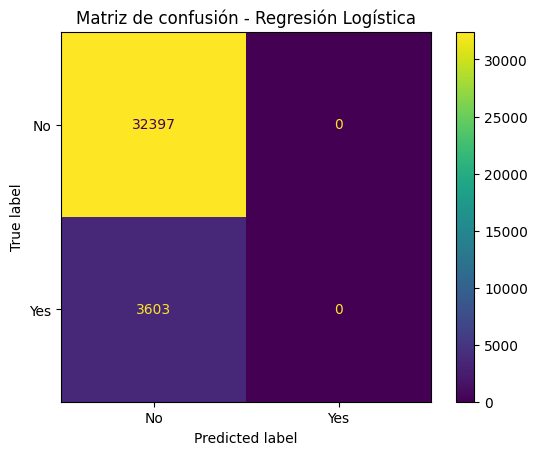

In [43]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

df_metricas = pd.DataFrame({
    "Modelo": ["Regresión Logística"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision_Yes": [
        precision_score(y_test, y_pred, pos_label="Yes", zero_division=0)
    ],
    "Recall_Yes": [
        recall_score(y_test, y_pred, pos_label="Yes", zero_division=0)
    ],
    "F1_Yes": [
        f1_score(y_test, y_pred, pos_label="Yes", zero_division=0)
    ]
})

display(df_metricas.round(4))

,Modelo,Accuracy,Precision_Yes,Recall_Yes,F1_Yes
0,Regresión Logística,0.900,0.000,0.000,0.000


## Parte 12 — Tabla de decisiones de modelamiento

Complete mínimo 6 decisiones de preprocesamiento y para una defina etapa, decisión, justificación, riesgo y control.

In [45]:
df_decisiones_modelamiento = pd.DataFrame([
    {
        "Etapa": "Definición del problema",
        "Decisión": "Seleccionar clasificación binaria",
        "Justificación": "La variable Diabetes tiene las categorías Yes y No.",
        "Riesgo": "Interpretar la clasificación como diagnóstico médico.",
        "Control": "Aclarar que el modelo es únicamente académico."
    },
    {
        "Etapa": "Variable objetivo",
        "Decisión": "Usar Diabetes como variable objetivo",
        "Justificación": "Es la variable que se desea predecir.",
        "Riesgo": "Utilizar registros donde el objetivo está vacío.",
        "Control": "Eliminar registros con Diabetes faltante."
    },
    {
        "Etapa": "Selección de variables",
        "Decisión": "Excluir Student ID",
        "Justificación": "Es un identificador y no una característica predictiva.",
        "Riesgo": "Introducir información irrelevante en el modelo.",
        "Control": "Excluir la variable antes de construir X."
    },
    {
        "Etapa": "Valores faltantes",
        "Decisión": "Imputar variables numéricas con la mediana",
        "Justificación": "Permite conservar registros sin eliminar datos innecesariamente.",
        "Riesgo": "La mediana puede no representar perfectamente los valores faltantes.",
        "Control": "Realizar la imputación dentro del pipeline."
    },
    {
        "Etapa": "Variables categóricas",
        "Decisión": "Aplicar OneHotEncoder",
        "Justificación": "Permite transformar categorías en variables numéricas.",
        "Riesgo": "Aparecer una categoría nueva durante la prueba.",
        "Control": "Usar handle_unknown='ignore'."
    },
    {
        "Etapa": "Escalamiento",
        "Decisión": "Estandarizar variables numéricas",
        "Justificación": "La regresión logística funciona mejor cuando las variables numéricas están en escalas comparables.",
        "Riesgo": "Realizar el escalamiento utilizando información del conjunto de prueba.",
        "Control": "Aplicar StandardScaler dentro del pipeline."
    },
    {
        "Etapa": "División de datos",
        "Decisión": "Usar 80% entrenamiento y 20% prueba",
        "Justificación": "Permite entrenar con la mayoría de los datos y reservar información independiente para evaluar.",
        "Riesgo": "Obtener una división poco representativa.",
        "Control": "Utilizar stratify=y y random_state=42."
    },
    {
        "Etapa": "Modelo",
        "Decisión": "Usar Regresión Logística",
        "Justificación": "Es apropiada como primer modelo para clasificación binaria.",
        "Riesgo": "No capturar relaciones complejas entre las variables.",
        "Control": "Comparar posteriormente con modelos no lineales."
    }
])

display(df_decisiones_modelamiento)

,Etapa,Decisión,Justificación,Riesgo,Control
0,Definición del problema,Seleccionar clasificación binaria,La variable Diabetes tiene las categorías Yes ...,Interpretar la clasificación como diagnóstico ...,Aclarar que el modelo es únicamente académico.
1,Variable objetivo,Usar Diabetes como variable objetivo,Es la variable que se desea predecir.,Utilizar registros donde el objetivo está vacío.,Eliminar registros con Diabetes faltante.
2,Selección de variables,Excluir Student ID,Es un identificador y no una característica pr...,Introducir información irrelevante en el modelo.,Excluir la variable antes de construir X.
3,Valores faltantes,Imputar variables numéricas con la mediana,Permite conservar registros sin eliminar datos...,La mediana puede no representar perfectamente ...,Realizar la imputación dentro del pipeline.
4,Variables categóricas,Aplicar OneHotEncoder,Permite transformar categorías en variables nu...,Aparecer una categoría nueva durante la prueba.,Usar handle_unknown='ignore'.
5,Escalamiento,Estandarizar variables numéricas,La regresión logística funciona mejor cuando l...,Realizar el escalamiento utilizando informació...,Aplicar StandardScaler dentro del pipeline.
6,División de datos,Usar 80% entrenamiento y 20% prueba,Permite entrenar con la mayoría de los datos y...,Obtener una división poco representativa.,Utilizar stratify=y y random_state=42.
7,Modelo,Usar Regresión Logística,Es apropiada como primer modelo para clasifica...,No capturar relaciones complejas entre las var...,Comparar posteriormente con modelos no lineales.


## Parte 13 — Guardar resultados

In [46]:
df_predicciones = X_test.copy()

df_predicciones["Diabetes_real"] = y_test.values
df_predicciones["Diabetes_predicha"] = y_pred

display(df_predicciones.head())

,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Smoking,Diabetes_real,Diabetes_predicha
100230,33.000,Male,158.502,72.771,AB,28.966,98.986,95.000,118.000,NaN,Yes,No,No
178756,19.000,Male,174.765,91.204,AB,NaN,98.788,79.000,102.000,162.000,No,Yes,No
196024,28.000,Female,NaN,98.739,AB,40.854,99.162,71.000,103.000,127.000,No,No,No
104600,29.000,Male,198.791,51.010,B,12.908,98.381,85.000,NaN,160.000,No,No,No
123601,24.000,Female,195.271,70.301,A,18.437,98.852,80.000,97.000,153.000,No,No,No


In [47]:
df.to_csv(
    "data/processed/medical_students_dataset_procesado.csv",
    index=False
)

df_predicciones.to_csv(
    "reports/predicciones_modelo_supervisado.csv",
    index=False
)

df_metricas.to_csv(
    "reports/metricas_modelo_supervisado.csv",
    index=False
)

df_decisiones_modelamiento.to_csv(
    "reports/decisiones_modelamiento_semana_4.csv",
    index=False
)

print("Archivos guardados correctamente.")

Archivos guardados correctamente.


## Parte 14 — Interpretación final

Responda:

1. ¿Qué problema de IA formuló?
2. ¿Qué modelo entrenó y por qué?
3. ¿Qué variables usó como predictoras?
4. ¿Qué métrica usó para evaluar?
5. ¿El resultado del modelo es aceptable? Justifique.
6. ¿Qué errores o limitaciones observa?
7. ¿Qué haría para mejorar el modelo en una siguiente versión?

**Respuesta:**

¿Qué problema de IA formuló?

Se formuló un problema de clasificación binaria cuyo objetivo es predecir si un estudiante pertenece a la categoría Yes o No de la variable Diabetes, utilizando características demográficas, físicas y relacionadas con su estado de salud.

¿Qué modelo entrenó y por qué?

Se entrenó un modelo de Regresión Logística. Se seleccionó porque es un modelo apropiado para problemas de clasificación binaria y permite establecer una primera línea base sencilla e interpretable.

¿Qué variables usó como predictoras?

Se utilizaron las variables Age, Gender, Height, Weight, Blood Type, BMI, Temperature, Heart Rate, Blood Pressure, Cholesterol y Smoking. La variable Student ID fue excluida porque únicamente funciona como identificador y no representa una característica útil para realizar la predicción.

¿Qué métrica usó para evaluar?

Se utilizaron Accuracy, Precision, Recall y F1-score. También se analizó la matriz de confusión para observar cómo se comportó el modelo con cada clase.

¿El resultado del modelo es aceptable? Justifique.

El resultado no es aceptable como modelo predictivo de diabetes, aunque la Accuracy es aproximadamente del 90 %. Esto ocurre porque existe un importante desbalance entre las clases. El modelo prácticamente clasifica todos los casos como No, por lo que obtiene una Accuracy alta, pero no logra identificar correctamente los casos Yes. Por esta razón, Precision, Recall y F1-score para la clase Yes presentan valores muy bajos o iguales a cero.

¿Qué errores o limitaciones observa?

La principal limitación es el desbalance de clases. Además, existen valores faltantes en el dataset y las relaciones entre las variables predictoras y la diabetes pueden no ser lineales, por lo que la Regresión Logística puede ser insuficiente para capturar relaciones más complejas.

¿Qué haría para mejorar el modelo en una siguiente versión?

En una siguiente versión se probarían técnicas para manejar el desbalance de clases, como utilizar class_weight="balanced". También se compararían otros modelos de clasificación, como Árboles de Decisión o Random Forest. Además, se utilizarían métricas como Recall, F1-score y ROC-AUC para seleccionar el modelo, en lugar de basarse únicamente en Accuracy.

## Parte 15 — Entrega

Suba el notebook ejecutado y los archivos generados.

Estructura sugerida:

```text
semana_4/
├── nombre_dataset.ipynb
├── data/
│   └── processed/
│       └── nombre_dataset_procesado.csv
└── reports/
    ├── predicciones_modelo_supervisado.csv
    ├── metricas_modelo_supervisado.csv
```